# HCP Brain Network Centrality Analysis

This notebook computes and visualizes centrality measures on the HCP structural connectivity (SC) network.

Sections:
1. **Load & Compute Centrality** – Degree, Betweenness, Closeness, Eigenvalue (λ₁), Eigenvector

**Libraries used:**
| Measure | Library |
|---|---|
| Degree centrality | `networkx` |
| Betweenness centrality | `networkx` |
| Closeness centrality | `networkx` |
| Eigenvector centrality | `networkx` |
| Eigenvalue (λ₁, spectral) | `numpy.linalg` |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx

from enigmatoolbox.datasets import load_sc

%matplotlib inline
print('Imports successful.')

Imports successful.


---
## Section 1: Load & Compute Centrality

We load the HCP cortical SC matrix and build a **weighted undirected** NetworkX graph.
Five centrality measures are computed:

| Measure | What it captures |
|---|---|
| **Degree** | Number of connections per node (binary) |
| **Betweenness** | How often a node lies on the shortest path between other nodes |
| **Closeness** | How quickly a node can reach all others (inverse mean distance) |
| **Eigenvector** | Importance weighted by the importance of neighbours (per-node) |
| **Eigenvalue λ₁** | Largest eigenvalue of adjacency matrix — global spectral connectivity strength |

In [3]:
# ── Load SC data ───────────────────────────────────────────────────────────────
sc_ctx, sc_ctx_labels, sc_sctx, sc_sctx_labels = load_sc()
n_ctx = sc_ctx.shape[0]  # 68

print(f'Cortical SC matrix: {sc_ctx.shape}')
print(f'Regions: {n_ctx}')

Cortical SC matrix: (68, 68)
Regions: 68


In [4]:
# ── Build weighted undirected NetworkX graph ───────────────────────────────────
# Nodes = cortical regions, edges = SC streamline weights
G = nx.from_numpy_array(sc_ctx)

# Attach region labels as node attributes
label_map = {i: sc_ctx_labels[i] for i in range(n_ctx)}
nx.set_node_attributes(G, label_map, 'region')

print(f'Nodes : {G.number_of_nodes()}')
print(f'Edges : {G.number_of_edges()}')
print(f'Is weighted : {nx.is_weighted(G)}')
print(f'Is connected: {nx.is_connected(G)}')

Nodes : 68
Edges : 697
Is weighted : True
Is connected: True


In [5]:
# ── 1. Degree Centrality ───────────────────────────────────────────────────────
# Normalised: deg(v) / (N-1)
degree_c = nx.degree_centrality(G)
degree_arr = np.array([degree_c[i] for i in range(n_ctx)])

print('Degree Centrality')
print(f'  Min   : {degree_arr.min():.4f}')
print(f'  Max   : {degree_arr.max():.4f}')
print(f'  Mean  : {degree_arr.mean():.4f}')
top5_idx = np.argsort(degree_arr)[::-1][:5]
print(f'  Top 5 : {[(sc_ctx_labels[i], round(degree_arr[i], 3)) for i in top5_idx]}')

Degree Centrality
  Min   : 0.0597
  Max   : 0.6119
  Mean  : 0.3060
  Top 5 : [(np.str_('R_superiorparietal'), np.float64(0.612)), (np.str_('R_insula'), np.float64(0.567)), (np.str_('L_insula'), np.float64(0.567)), (np.str_('L_superiorparietal'), np.float64(0.522)), (np.str_('R_superiorfrontal'), np.float64(0.507))]


In [6]:
# ── 2. Betweenness Centrality ──────────────────────────────────────────────────
# Uses inverse weight as distance so higher SC = shorter path
# normalized=True → divide by (N-1)(N-2)/2
betweenness_c = nx.betweenness_centrality(G, weight='weight', normalized=True)
betweenness_arr = np.array([betweenness_c[i] for i in range(n_ctx)])

print('Betweenness Centrality')
print(f'  Min   : {betweenness_arr.min():.4f}')
print(f'  Max   : {betweenness_arr.max():.4f}')
print(f'  Mean  : {betweenness_arr.mean():.4f}')
top5_idx = np.argsort(betweenness_arr)[::-1][:5]
print(f'  Top 5 : {[(sc_ctx_labels[i], round(betweenness_arr[i], 4)) for i in top5_idx]}')

Betweenness Centrality
  Min   : 0.0000
  Max   : 0.0534
  Mean  : 0.0149
  Top 5 : [(np.str_('R_medialorbitofrontal'), np.float64(0.0534)), (np.str_('L_parahippocampal'), np.float64(0.0525)), (np.str_('R_insula'), np.float64(0.052)), (np.str_('R_isthmuscingulate'), np.float64(0.0488)), (np.str_('R_parahippocampal'), np.float64(0.0488))]


In [7]:
# ── 3. Closeness Centrality ────────────────────────────────────────────────────
# distance = 1/weight so stronger SC = closer
# Add a small epsilon to avoid division by zero on zero-weight edges
G_close = G.copy()
for u, v, d in G_close.edges(data=True):
    d['distance'] = 1.0 / (d['weight'] + 1e-9)

closeness_c = nx.closeness_centrality(G_close, distance='distance')
closeness_arr = np.array([closeness_c[i] for i in range(n_ctx)])

print('Closeness Centrality')
print(f'  Min   : {closeness_arr.min():.4f}')
print(f'  Max   : {closeness_arr.max():.4f}')
print(f'  Mean  : {closeness_arr.mean():.4f}')
top5_idx = np.argsort(closeness_arr)[::-1][:5]
print(f'  Top 5 : {[(sc_ctx_labels[i], round(closeness_arr[i], 4)) for i in top5_idx]}')

Closeness Centrality
  Min   : 3.4237
  Max   : 5.9470
  Mean  : 4.5430
  Top 5 : [(np.str_('R_superiorparietal'), np.float64(5.947)), (np.str_('R_superiorfrontal'), np.float64(5.8278)), (np.str_('L_superiorfrontal'), np.float64(5.7244)), (np.str_('L_superiorparietal'), np.float64(5.6747)), (np.str_('R_precuneus'), np.float64(5.3475))]


In [8]:
# ── 4. Eigenvector Centrality ──────────────────────────────────────────────────
# Per-node: score proportional to sum of neighbours' scores (principal eigenvector)
# eigenvector_centrality_numpy is more stable than the power-iteration version
eigenvec_c = nx.eigenvector_centrality_numpy(G, weight='weight')
eigenvec_arr = np.array([eigenvec_c[i] for i in range(n_ctx)])

print('Eigenvector Centrality')
print(f'  Min   : {eigenvec_arr.min():.4f}')
print(f'  Max   : {eigenvec_arr.max():.4f}')
print(f'  Mean  : {eigenvec_arr.mean():.4f}')
top5_idx = np.argsort(eigenvec_arr)[::-1][:5]
print(f'  Top 5 : {[(sc_ctx_labels[i], round(eigenvec_arr[i], 4)) for i in top5_idx]}')

Eigenvector Centrality
  Min   : 0.0263
  Max   : 0.2333
  Mean  : 0.1136
  Top 5 : [(np.str_('R_superiorparietal'), np.float64(0.2333)), (np.str_('R_superiorfrontal'), np.float64(0.2166)), (np.str_('L_superiorfrontal'), np.float64(0.209)), (np.str_('L_superiorparietal'), np.float64(0.2076)), (np.str_('L_insula'), np.float64(0.192))]


In [9]:
# ── 5. Eigenvalue Spectrum (λ₁ = spectral radius) ─────────────────────────────
# eigh: efficient for real symmetric matrices (SC is symmetric)
# Returns eigenvalues in ascending order → λ₁ is the last one
eigenvalues, eigenvectors = np.linalg.eigh(sc_ctx)
eigenvalues_sorted = eigenvalues[::-1]        # descending
eigenvectors_sorted = eigenvectors[:, ::-1]   # corresponding vectors

lambda1  = eigenvalues_sorted[0]   # spectral radius
v1       = eigenvectors_sorted[:, 0]           # principal eigenvector

print(f'Spectral radius λ₁ : {lambda1:.4f}')
print(f'Top 5 eigenvalues  : {eigenvalues_sorted[:5].round(4)}')
print(f'Explained variance by λ₁: {(lambda1**2 / (eigenvalues**2).sum() * 100):.1f}%')

top5_idx = np.argsort(np.abs(v1))[::-1][:5]
print(f'Top 5 regions in principal eigenvector v₁:')
for i in top5_idx:
    print(f'  {sc_ctx_labels[i]:<35} v₁ = {v1[i]:.4f}')

Spectral radius λ₁ : 173.5366
Top 5 eigenvalues  : [173.5366 101.6855  91.3303  70.8075  68.3142]
Explained variance by λ₁: 36.3%
Top 5 regions in principal eigenvector v₁:
  R_superiorparietal                  v₁ = 0.2333
  R_superiorfrontal                   v₁ = 0.2166
  L_superiorfrontal                   v₁ = 0.2090
  L_superiorparietal                  v₁ = 0.2076
  L_insula                            v₁ = 0.1920


In [10]:
# ── Summary table: all centrality measures per region ─────────────────────────
centrality_df = pd.DataFrame({
    'Region'          : sc_ctx_labels,
    'Degree'          : degree_arr.round(4),
    'Betweenness'     : betweenness_arr.round(4),
    'Closeness'       : closeness_arr.round(4),
    'Eigenvector'     : eigenvec_arr.round(4),
    'v1_component'    : np.abs(v1).round(4),   # |principal eigenvector component|
})

# Rank each measure
for col in ['Degree', 'Betweenness', 'Closeness', 'Eigenvector', 'v1_component']:
    centrality_df[col + '_rank'] = centrality_df[col].rank(ascending=False).astype(int)

print(f'Spectral radius λ₁ = {lambda1:.4f}  (global network metric, not per-node)')
print()
print(centrality_df[['Region','Degree','Betweenness','Closeness','Eigenvector','v1_component']]
      .sort_values('Eigenvector', ascending=False)
      .head(15)
      .to_string(index=False))

Spectral radius λ₁ = 173.5366  (global network metric, not per-node)

                Region  Degree  Betweenness  Closeness  Eigenvector  v1_component
    R_superiorparietal  0.6119       0.0226     5.9470       0.2333        0.2333
     R_superiorfrontal  0.5075       0.0014     5.8278       0.2166        0.2166
     L_superiorfrontal  0.4925       0.0063     5.7244       0.2090        0.2090
    L_superiorparietal  0.5224       0.0063     5.6747       0.2076        0.2076
              L_insula  0.5672       0.0412     5.1508       0.1920        0.1920
              R_insula  0.5672       0.0520     5.2048       0.1837        0.1837
           R_precuneus  0.4627       0.0118     5.3475       0.1741        0.1741
L_rostralmiddlefrontal  0.4478       0.0217     5.2860       0.1731        0.1731
           L_precuneus  0.4179       0.0081     5.3194       0.1715        0.1715
R_rostralmiddlefrontal  0.3881       0.0077     5.2241       0.1550        0.1550
    L_isthmuscingulate  0.44

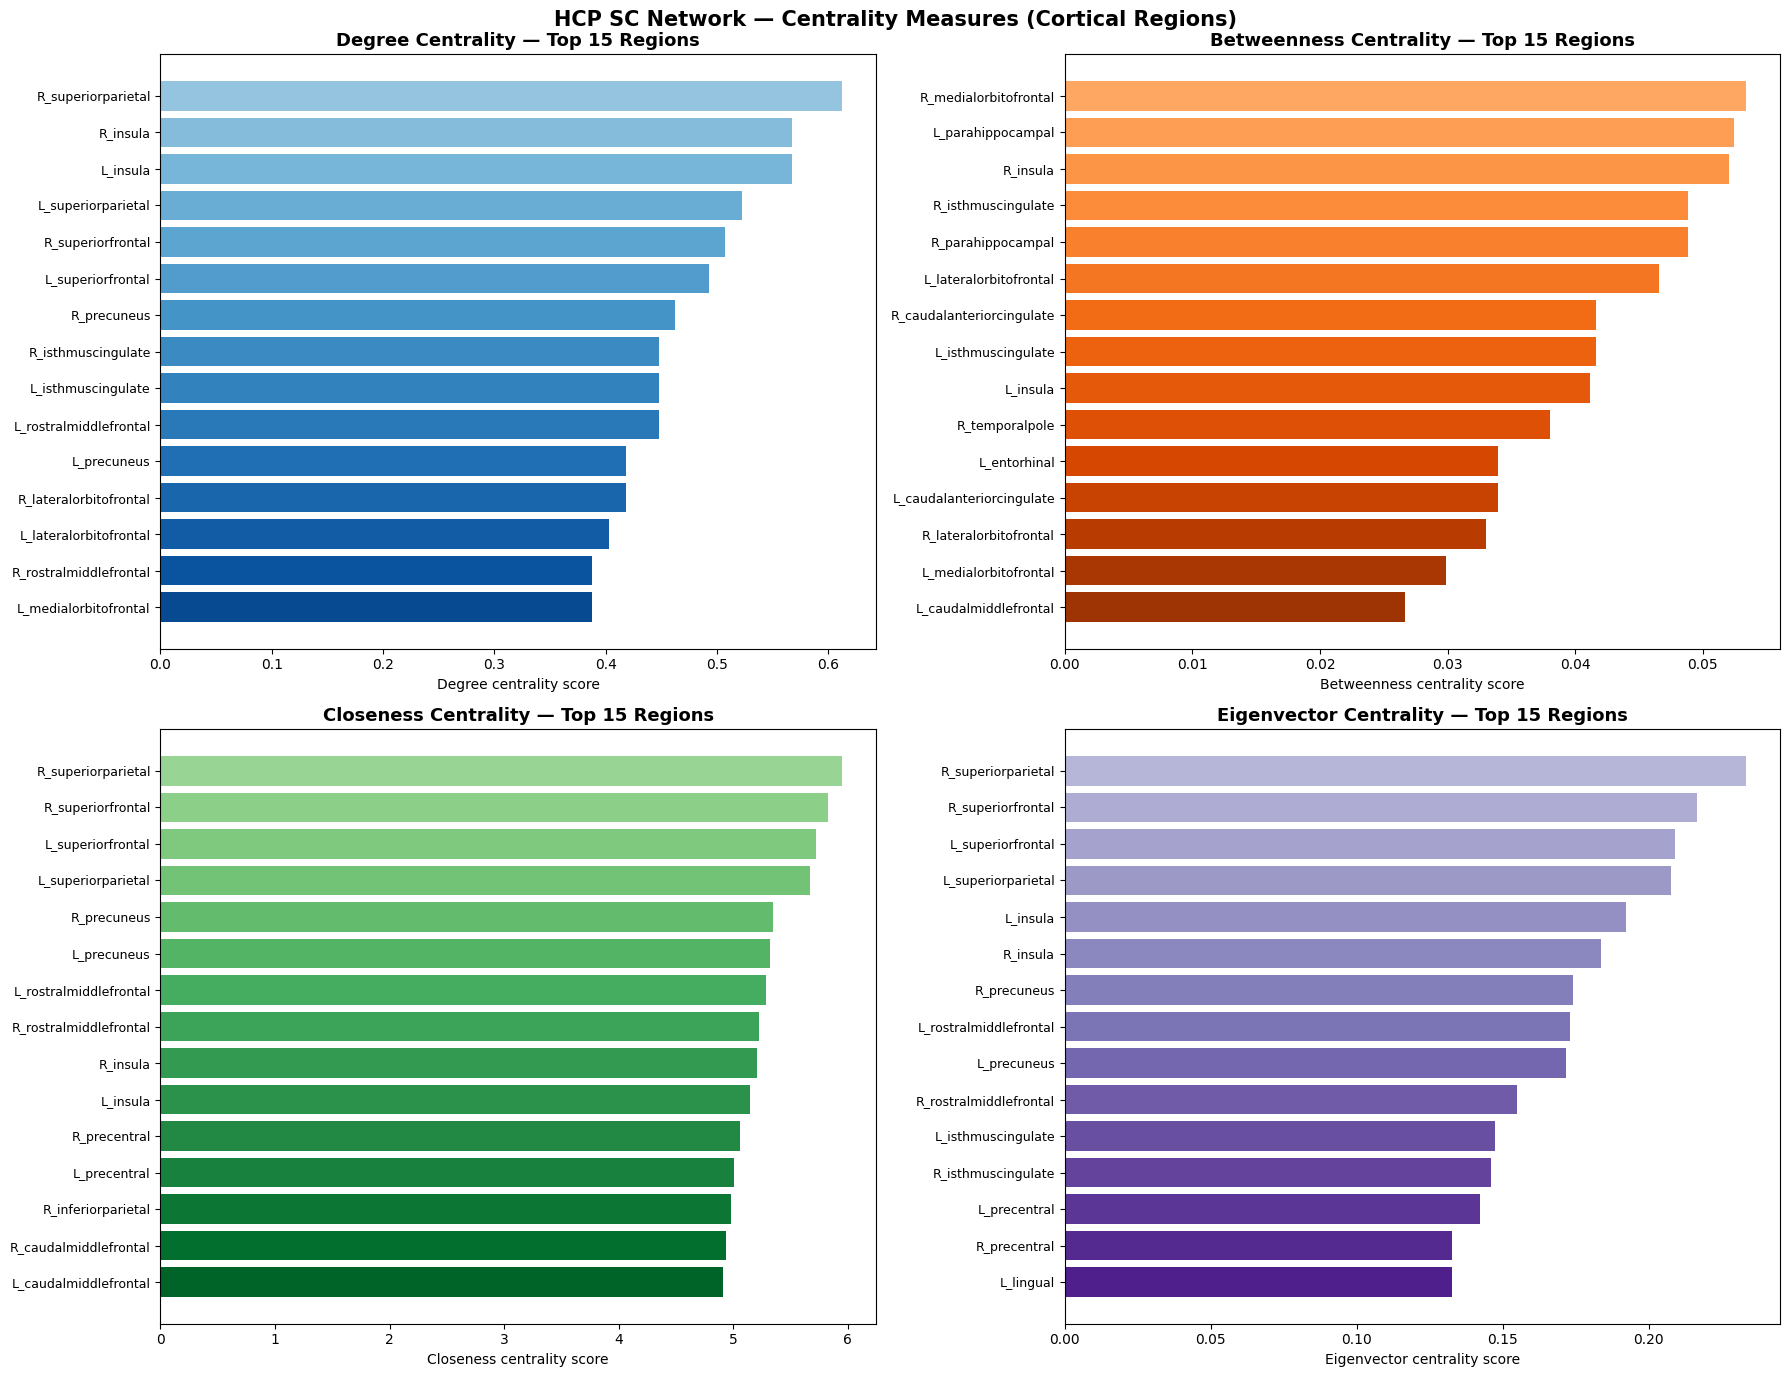

In [11]:
# ── Visualize: top-15 bar charts for each centrality measure ──────────────────
measures = [
    ('Degree',      degree_arr,      'steelblue'),
    ('Betweenness', betweenness_arr, 'darkorange'),
    ('Closeness',   closeness_arr,   'mediumseagreen'),
    ('Eigenvector', eigenvec_arr,    'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (name, arr, color) in zip(axes, measures):
    top15_idx = np.argsort(arr)[::-1][:15]
    labels_top = [sc_ctx_labels[i] for i in top15_idx]
    values_top = arr[top15_idx]

    colors = plt.cm.Blues(np.linspace(0.4, 0.9, 15))[::-1] if color == 'steelblue' else \
             plt.cm.Oranges(np.linspace(0.4, 0.9, 15))[::-1] if color == 'darkorange' else \
             plt.cm.Greens(np.linspace(0.4, 0.9, 15))[::-1] if color == 'mediumseagreen' else \
             plt.cm.Purples(np.linspace(0.4, 0.9, 15))[::-1]

    ax.barh(labels_top[::-1], values_top[::-1], color=colors)
    ax.set_title(f'{name} Centrality — Top 15 Regions', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{name} centrality score')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('HCP SC Network — Centrality Measures (Cortical Regions)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_centrality_bars.png', dpi=150, bbox_inches='tight')
plt.show()

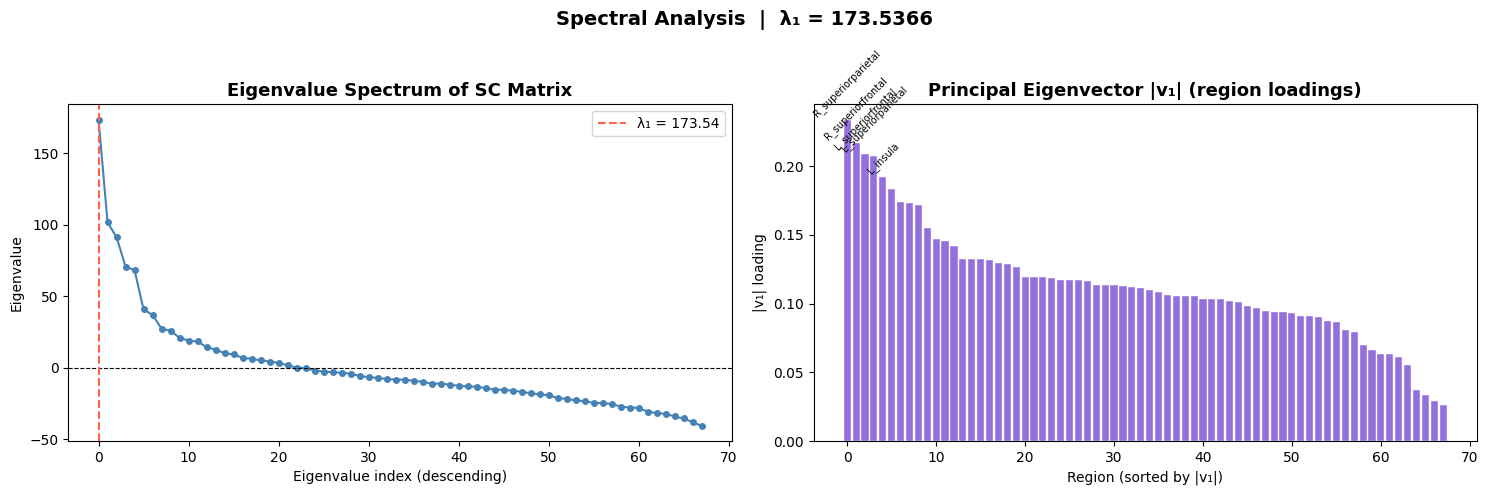

In [12]:
# ── Eigenvalue spectrum ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Full spectrum
axes[0].plot(eigenvalues_sorted, 'o-', color='steelblue', markersize=4)
axes[0].axhline(0, color='k', linewidth=0.8, linestyle='--')
axes[0].axvline(0, color='tomato', linewidth=1.5, linestyle='--', label=f'λ₁ = {lambda1:.2f}')
axes[0].set_title('Eigenvalue Spectrum of SC Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Eigenvalue index (descending)')
axes[0].set_ylabel('Eigenvalue')
axes[0].legend()

# Principal eigenvector v₁ — per region loading
v1_abs = np.abs(v1)
sorted_v1_idx = np.argsort(v1_abs)[::-1]
axes[1].bar(range(n_ctx), v1_abs[sorted_v1_idx], color='mediumpurple', edgecolor='white', linewidth=0.3)
axes[1].set_title('Principal Eigenvector |v₁| (region loadings)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Region (sorted by |v₁|)')
axes[1].set_ylabel('|v₁| loading')
# Label top 5
for rank, i in enumerate(sorted_v1_idx[:5]):
    axes[1].text(rank, v1_abs[i] + 0.001, sc_ctx_labels[i], fontsize=7,
                 ha='center', va='bottom', rotation=45)

plt.suptitle(f'Spectral Analysis  |  λ₁ = {lambda1:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_eigenspectrum.png', dpi=150, bbox_inches='tight')
plt.show()

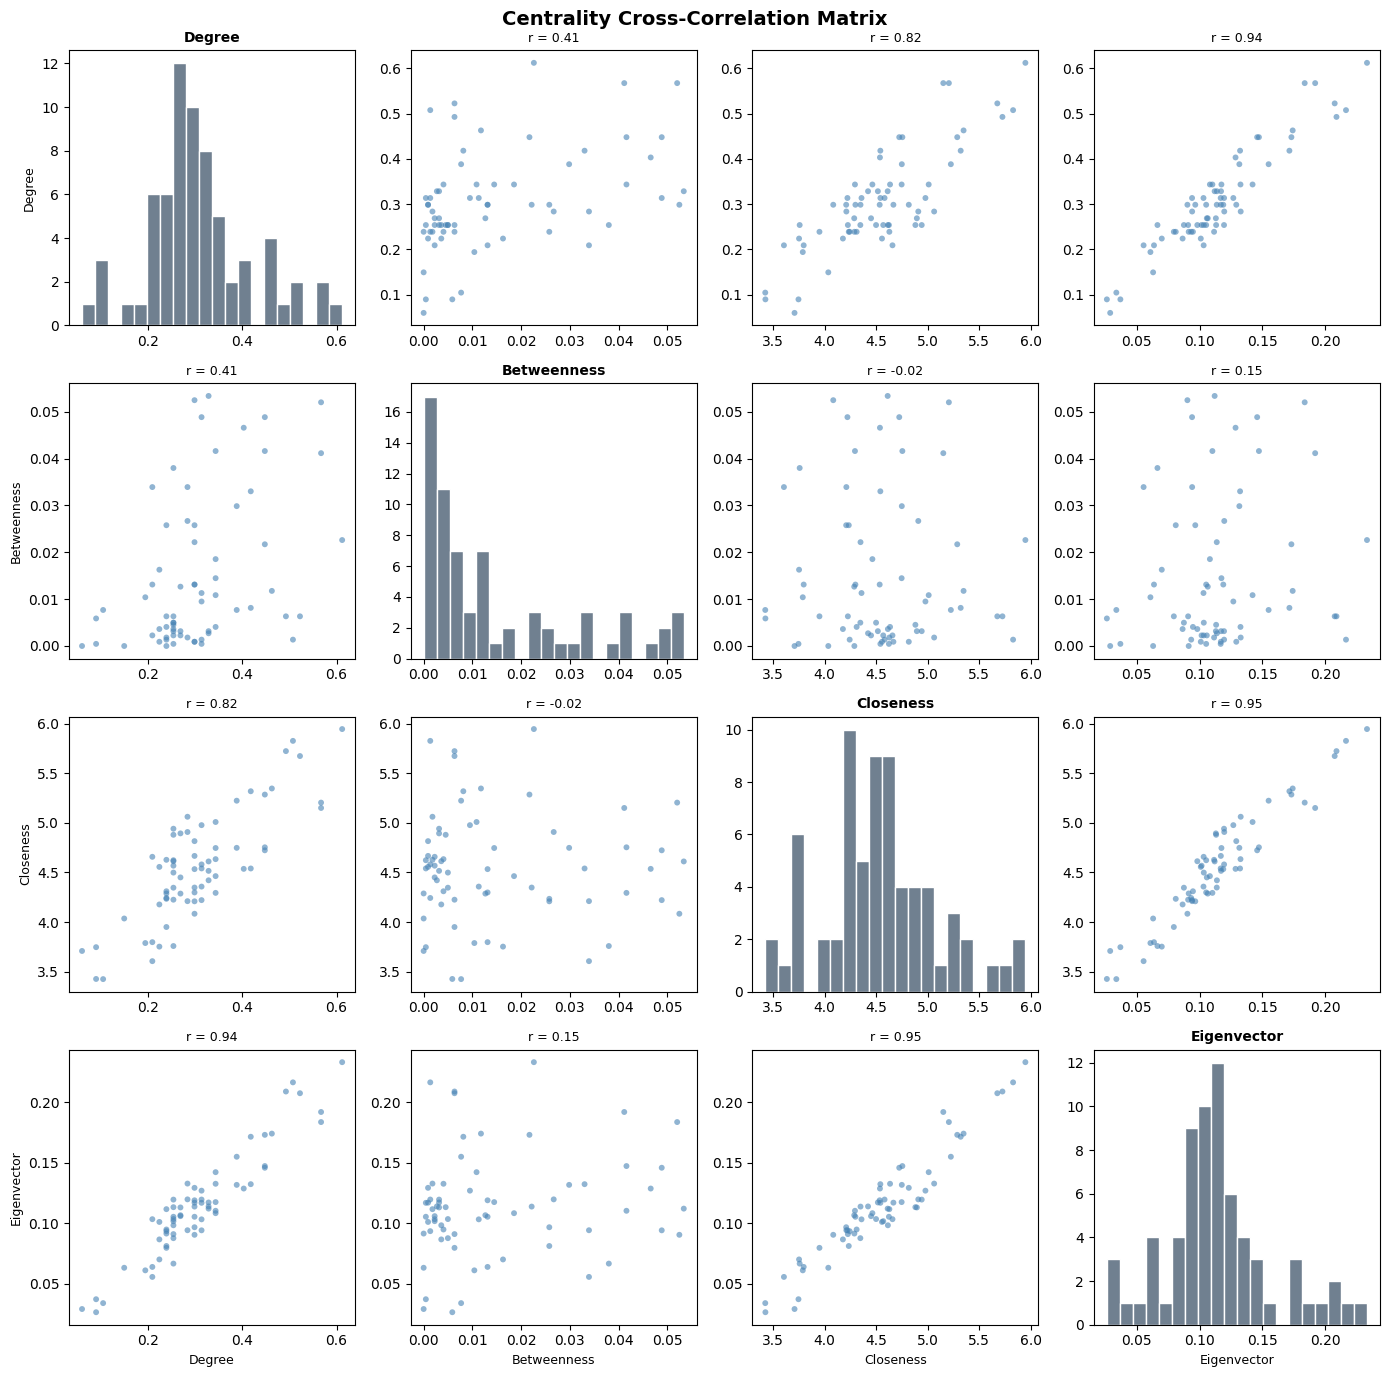

In [13]:
# ── Cross-measure scatter matrix ───────────────────────────────────────────────
# How correlated are the different centrality rankings?
measure_names = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector']
measure_arrays = [degree_arr, betweenness_arr, closeness_arr, eigenvec_arr]
n_m = len(measure_names)

fig, axes = plt.subplots(n_m, n_m, figsize=(14, 14))

for i in range(n_m):
    for j in range(n_m):
        ax = axes[i, j]
        if i == j:
            ax.hist(measure_arrays[i], bins=20, color='slategray', edgecolor='white')
            ax.set_title(measure_names[i], fontsize=10, fontweight='bold')
        else:
            r = np.corrcoef(measure_arrays[j], measure_arrays[i])[0, 1]
            ax.scatter(measure_arrays[j], measure_arrays[i], s=18, alpha=0.6,
                       color='steelblue', edgecolors='none')
            ax.set_title(f'r = {r:.2f}', fontsize=9)
        if i == n_m - 1:
            ax.set_xlabel(measure_names[j], fontsize=9)
        if j == 0:
            ax.set_ylabel(measure_names[i], fontsize=9)

plt.suptitle('Centrality Cross-Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_centrality_scatter.png', dpi=150, bbox_inches='tight')
plt.show()